## Build Basic Chatbot With Langraph(Graph APi)

In [1]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages



In [2]:
class State(TypedDict):
    ## Messaage have the type list . add message function
    ## in the annotation defines how this state key should be updated 
    # (in the case it appends messages to the list , rather than overwitting them)
    messages:Annotated[list,add_messages]


graph_builder=StateGraph(State)



In [3]:
graph_builder

In [4]:
import os 
from dotenv import load_dotenv
load_dotenv()


True

In [5]:
from langchain_nvidia_ai_endpoints import ChatNVIDIA

llm = ChatNVIDIA(model="nvidia/nemotron-3-super-120b-a12b")
response = llm.invoke("Hello")   
response

AIMessage(content="Hello! 👋 How can I assist you today? Whether you have a question, need help with something, or just want to chat—I'm here for you! 😊", additional_kwargs={'reasoning_content': 'Okay, the user just said "Hello". I should respond in a friendly and welcoming manner. Since they haven\'t specified any particular topic or need, I\'ll keep it open-ended to encourage them to share more if they want. I\'ll use a simple greeting and ask how I can assist them today. This approach is polite, neutral, and leaves the conversation open for whatever they might need next.', '_reasoning_api_fields': ['reasoning_content']}, response_metadata={'content': "Hello! 👋 How can I assist you today? Whether you have a question, need help with something, or just want to chat—I'm here for you! 😊", 'role': 'assistant', 'reasoning_content': 'Okay, the user just said "Hello". I should respond in a friendly and welcoming manner. Since they haven\'t specified any particular topic or need, I\'ll keep it

In [6]:
def chatbot(state:State):
    return{"messages":[llm.invoke(state["messages"])]}

In [7]:

graph_builder=StateGraph(State)
## adding nodes
graph_builder.add_node("llmchatbot",chatbot)
## adding edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

##Compile the graph
graph=graph_builder.compile()


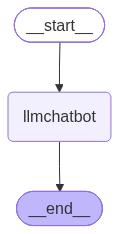

In [8]:
# Visualize graph

from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [9]:
graph.invoke({"messages":"Hii"})

{'messages': [HumanMessage(content='Hii', additional_kwargs={}, response_metadata={}, id='0ba306e5-02e9-424b-939a-cf834a7bb71d'),
  AIMessage(content='Hey! How can I help you today?', additional_kwargs={'reasoning_content': 'We need to respond friendly. The user said "Hii". Probably just a greeting. We respond with greeting.', '_reasoning_api_fields': ['reasoning_content']}, response_metadata={'content': 'Hey! How can I help you today?', 'role': 'assistant', 'reasoning_content': 'We need to respond friendly. The user said "Hii". Probably just a greeting. We respond with greeting.', 'token_usage': {'prompt_tokens': 18, 'completion_tokens': 35, 'total_tokens': 53}, 'finish_reason': 'stop', 'model_name': 'nvidia/nemotron-3-super-120b-a12b'}, id='lc_run--019ffac3-0ae8-7831-8958-3399509bc84a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 18, 'output_tokens': 35, 'total_tokens': 53}, role='assistant')]}

In [10]:
response=graph.invoke({"messages":"Hii"})

In [11]:
response

{'messages': [HumanMessage(content='Hii', additional_kwargs={}, response_metadata={}, id='0cb1952c-4bce-4bef-a23d-f4c84891c2c5'),
  AIMessage(content="Hey there! 😊 How's your day going? I'm here to chat, help with questions, or just keep you company—whatever you need! What's on your mind? ✨", additional_kwargs={'reasoning_content': 'Okay, the user just said "Hii". Hmm, that\'s a very casual and friendly greeting. They\'re probably just testing if I\'m responsive or wanting to start a conversation in a lighthearted way. \n\nSince they used "Hii" with extra \'i\'s, they seem to be in a playful or relaxed mood—maybe bored, curious, or just killing time. No urgency or specific request here. \n\nI should keep it warm and open-ended to match their tone. No need for formalities; a smiley emoji would feel natural here. Gotta leave the ball in their court though—they might want to chat about anything, or maybe they\'ll reveal their real intent later. \n\n...Also, no red flags in this message. S

In [12]:
response["messages"][-1]

AIMessage(content="Hey there! 😊 How's your day going? I'm here to chat, help with questions, or just keep you company—whatever you need! What's on your mind? ✨", additional_kwargs={'reasoning_content': 'Okay, the user just said "Hii". Hmm, that\'s a very casual and friendly greeting. They\'re probably just testing if I\'m responsive or wanting to start a conversation in a lighthearted way. \n\nSince they used "Hii" with extra \'i\'s, they seem to be in a playful or relaxed mood—maybe bored, curious, or just killing time. No urgency or specific request here. \n\nI should keep it warm and open-ended to match their tone. No need for formalities; a smiley emoji would feel natural here. Gotta leave the ball in their court though—they might want to chat about anything, or maybe they\'ll reveal their real intent later. \n\n...Also, no red flags in this message. Safe to assume good vibes only. 😊', '_reasoning_api_fields': ['reasoning_content']}, response_metadata={'content': "Hey there! 😊 How'

In [13]:
response["messages"][-1].content

"Hey there! 😊 How's your day going? I'm here to chat, help with questions, or just keep you company—whatever you need! What's on your mind? ✨"

In [14]:
for event in graph.stream({"messages":"Hii How are you"}):
    print(event)

{'llmchatbot': {'messages': [AIMessage(content="Hey there! 😊 I'm doing great—thanks for asking! As an AI, I don't have feelings quite like humans do, but I'm always excited to chat and help out. How about you? How's your day going? I'm here to listen or help with anything you need! ✨", additional_kwargs={'reasoning_content': 'Okay, the user said "Hii How are you" with a double \'i\' in "Hii" which feels casual and friendly. They\'re probably just starting a conversation, maybe testing if I\'m responsive or looking for a light-hearted exchange. \n\nHmm, they didn\'t give any context about their mood or needs, so I should keep it open-ended but warm. The typo ("Hii") suggests they might be typing quickly on mobile or feeling relaxed—no need to overcorrect it, just mirror their casual tone. \n\nSince they asked how I am, I\'ll acknowledge it politely but pivot to them because as an AI, I don\'t have feelings—I should clarify that gently to avoid confusion while keeping it upbeat. The emoj

In [15]:
for event in graph.stream({"messages":"Hii How are you"}):
    for value in event.values():
        print(value)

{'messages': [AIMessage(content='Hey there! 😊 I\'m doing great—thanks for asking! (And hey, I love the extra "i" in "Hii"—it gives me cheerful vibes!) As an AI, I don\'t have feelings like humans do, but I\'m always excited to chat, help, or just listen if you need someone to talk to.  \n\nHow about you? How\'s your day going? I\'m all ears (or well, all text! 😄). ✨', additional_kwargs={'reasoning_content': 'Okay, the user just said "Hii How are you" with a casual greeting. Hmm, they seem to be in a friendly, relaxed mood—probably just testing if I\'m responsive or making small talk. \n\nI should keep it warm and approachable since they used "Hii" (with two i\'s, which feels playful). No need for over-the-top formality here. \n\nNoticing they didn\'t ask anything specific yet—just a check-in. So my reply should:  \n- Acknowledge their greeting enthusiastically (matching their energy)  \n- Keep it open-ended to invite them to share more if they want  \n- Avoid making assumptions about w

In [16]:
for event in graph.stream({"messages":"Hii How are you"}):
    for value in event.values():
        print(value["messages"][-1].content)

Hey there! 😊 I'm doing great—thanks for asking! Even though I'm an AI and don't have feelings quite like humans do, I'm always excited to chat and help out. How about you? How's your day going? I'd love to hear what's on your mind! ✨


# ChatBot with Tool


In [17]:
from langchain_tavily import TavilySearch

tool=TavilySearch(max_results=2)
tool.invoke("What is Langraph")

{'query': 'What is Langraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://sumble.com/tech/langraph',
   'title': 'What is Langraph? Competitors, Complementary Techs & Usage | Sumble',
   'content': "LangGraph is a framework for building robust and stateful conversational applications using Large Language Models (LLMs). It allows developers to define complex conversation flows as graphs, where each node represents a specific task or decision point. LangGraph excels in creating sophisticated conversational agents that can handle multiple turns, remember previous interactions, and adapt their behavior based on user input and internal state. It's commonly used to build chatbots, virtual [...] LlamaIndex\n\nLlamaIndex is a framework for building LLM-powered applications by ingesting and structuring private or domain-specific data. Langraph aims to provide an alternative composition strategy, creating overlap and competition.\n\nNumber of organ

In [18]:
from langchain_tavily import TavilySearch

tool=TavilySearch(max_results=2)
tool.invoke("Today date is 13 agust 2026 what are the upcoming latest 5g tablets will goint to launch in india september 2026 -2027 at price range of 30-35K")

{'query': 'Today date is 13 agust 2026 what are the upcoming latest 5g tablets will goint to launch in india september 2026 -2027 at price range of 30-35K',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.bajajfinserv.in/5g-tablet-price-list-in-india',
   'title': '5G Tablets’ Price List in India (2026) | Bajaj Finance',
   'content': '5G tablets - Price list in India (2026)\n\n5G tablets in India now span a wide price range, starting from Rs. 20,999 and going up to Rs. 1,39,899. Whether you are a student, professional, gamer, or creative user, these tablets offer fast connectivity, vibrant displays, and powerful processors to meet your needs across work, entertainment, and productivity. [...] 9. Lenovo Tab P11 5G  \n This tablet features a Snapdragon 750G processor and a 2K display, offering great visuals and performance for work and play. It is best suited for users who want a mid-range tablet with premium features.\n\n|  |  |\n --- |\n

In [19]:
## Custom Function 

def multiply(a:int,b:int)->int:
    """_summary_
    
    Args:
        a (int): _description_ 
        b (int): _description_

        Returns:
                int: _description_
        
        
        
        """

In [20]:
## Custom Function 

def multiply(a:int,b:int)->int:
    """_summary_
    
    Args:
        a (int): First Int
        b (int): Second Int

        Returns:
                int: output_int

        
        
        
        """
    return a*b

In [21]:
tools=[tool,multiply]

In [22]:
llm_with_tool=llm.bind_tools(tools)

In [23]:
llm_with_tool

_ChatModelBinding(bound=ChatNVIDIA(metadata={'lc_versions': {'langchain-core': '1.5.4', 'langchain': '1.3.15', 'langchain-nvidia-ai-endpoints': '1.4.3'}}, profile={}, base_url='https://integrate.api.nvidia.com/v1', model='nvidia/nemotron-3-super-120b-a12b', default_headers={}, model_kwargs={}), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurate, and citation-backed results.Input should be a search query.', 'parameters': {'properties': {'query': {'description': 'Search query to look up', 'type': 'string'}, 'include_domains': {'anyOf': [{'items': {'type': 'string'}, 'type': 'array'}, {'type': 'null'}], 'default': [], 'description': 'A li

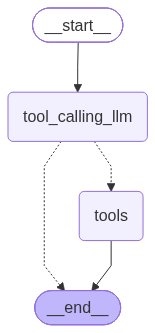

In [24]:
## Stategraph

from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node defination

def tool_calling_llm(state:State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}
   


## Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
    # If the latest message (result) from assitant is a tool call --> tools_condition routes to tools
    # If the latest_message (result) from assitant is a not tool call _> tools_condition routes to end
)

builder.add_edge("tools",END)


## Compile the graph 
graph=builder.compile()

from IPython.display import Image , display
display(Image(graph.get_graph().draw_mermaid_png()))

In [25]:
graph.invoke({  "messages": "what is recent Ai news" })

{'messages': [HumanMessage(content='what is recent Ai news', additional_kwargs={}, response_metadata={}, id='afdcfb0f-689c-417f-ab26-f6f8c0707903'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "The user wants recent AI news. Use tavily_search with query recent AI news, maybe topic news, time_range week or month. Let's do a search.", '_reasoning_api_fields': ['reasoning_content'], 'tool_calls': [{'id': 'chatcmpl-tool-94f8d3f44e054cc1', 'type': 'function', 'function': {'name': 'tavily_search', 'arguments': '{"query": "recent AI news", "topic": "news", "time_range": "week", "search_depth": "basic"}'}}]}, response_metadata={'content': None, 'tool_calls': [{'id': 'chatcmpl-tool-94f8d3f44e054cc1', 'type': 'function', 'function': {'name': 'tavily_search', 'arguments': '{"query": "recent AI news", "topic": "news", "time_range": "week", "search_depth": "basic"}'}}], 'role': 'assistant', 'reasoning_content': "The user wants recent AI news. Use tavily_search with query recent 

In [26]:
response=graph.invoke({  "messages": "what is recent Ai news" })

In [27]:
response["messages"][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://mynews13.com/fl/orlando/inside-city-hall/2026/08/07/reporter-looks-at-the-latest-ai-news", "title": "Reporter looks at the latest AI news", "content": "BY   Spectrum News Staff  New York City\\n\\nPUBLISHED 8:30 PM ET Aug. 07, 2026 PUBLISHED August 7, 2026 @8:30 PM\\n\\nArtificial intelligence was in the political headlines this week with the White House finalizing a framework for how to regulate the most advanced AI models.\\n\\nOther recent headlines have raised profound issues of safety and security with AI models.\\n\\nVeronica Irwin, a senior AI policy reporter for the AI new site Transformer, which tracks all the latest developments in the technology, joined NY1’s Bobby Cuza on “Inside City Hall” Friday to discuss more.\\n\\nTap the video player above to watch the interview. [...] IMPACT FEESJudge rules against impact fee increases in Palm Coast\\n\\nTEST FLIGHTSPo

In [28]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

what is recent Ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (chatcmpl-tool-9dde2cde85d3a6cf)
 Call ID: chatcmpl-tool-9dde2cde85d3a6cf
  Args:
    query: recent AI news
    topic: news
    time_range: week
    search_depth: advanced
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://mynews13.com/fl/orlando/inside-city-hall/2026/08/07/reporter-looks-at-the-latest-ai-news", "title": "Reporter looks at the latest AI news", "content": "BY   Spectrum News Staff  New York City\n\nPUBLISHED 8:30 PM ET Aug. 07, 2026 PUBLISHED August 7, 2026 @8:30 PM\n\nArtificial intelligence was in the political headlines this week with the White House finalizing a framework for how to regulate 

In [29]:
response=graph.invoke({"messages":"What is 2 multiply by 3"})

for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 2 multiply by 3
================================== Ai Message ==================================
Tool Calls:
  multiply (chatcmpl-tool-b7ddc8affd095881)
 Call ID: chatcmpl-tool-b7ddc8affd095881
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6


In [30]:
response=graph.invoke({"messages":"What is 2 multiply by 3 and then multiply  10"})

for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 2 multiply by 3 and then multiply  10
================================== Ai Message ==================================
Tool Calls:
  multiply (chatcmpl-tool-b7c7a96f42f72f1a)
 Call ID: chatcmpl-tool-b7c7a96f42f72f1a
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6


In [31]:
response=graph.invoke({"messages":" give me  recent AI News and then what is  2 multiply by 3 and then multiply by 10"})

for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

 give me  recent AI News and then what is  2 multiply by 3 and then multiply by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (chatcmpl-tool-88e48562ae16dd78)
 Call ID: chatcmpl-tool-88e48562ae16dd78
  Args:
    query: recent AI news
    time_range: week
    topic: news
    search_depth: basic
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://mynews13.com/fl/orlando/inside-city-hall/2026/08/07/reporter-looks-at-the-latest-ai-news", "title": "Reporter looks at the latest AI news", "content": "Artificial intelligence was in the political headlines this week with the White House finalizing a framework for how to regulate the most advanced AI models.\n\nOther recent headlines hav

### So in these kind of question 1st Q attempt and q direct end but llm not suppose to ans q 2 so for these kind of deal with problem react agent came in pictures

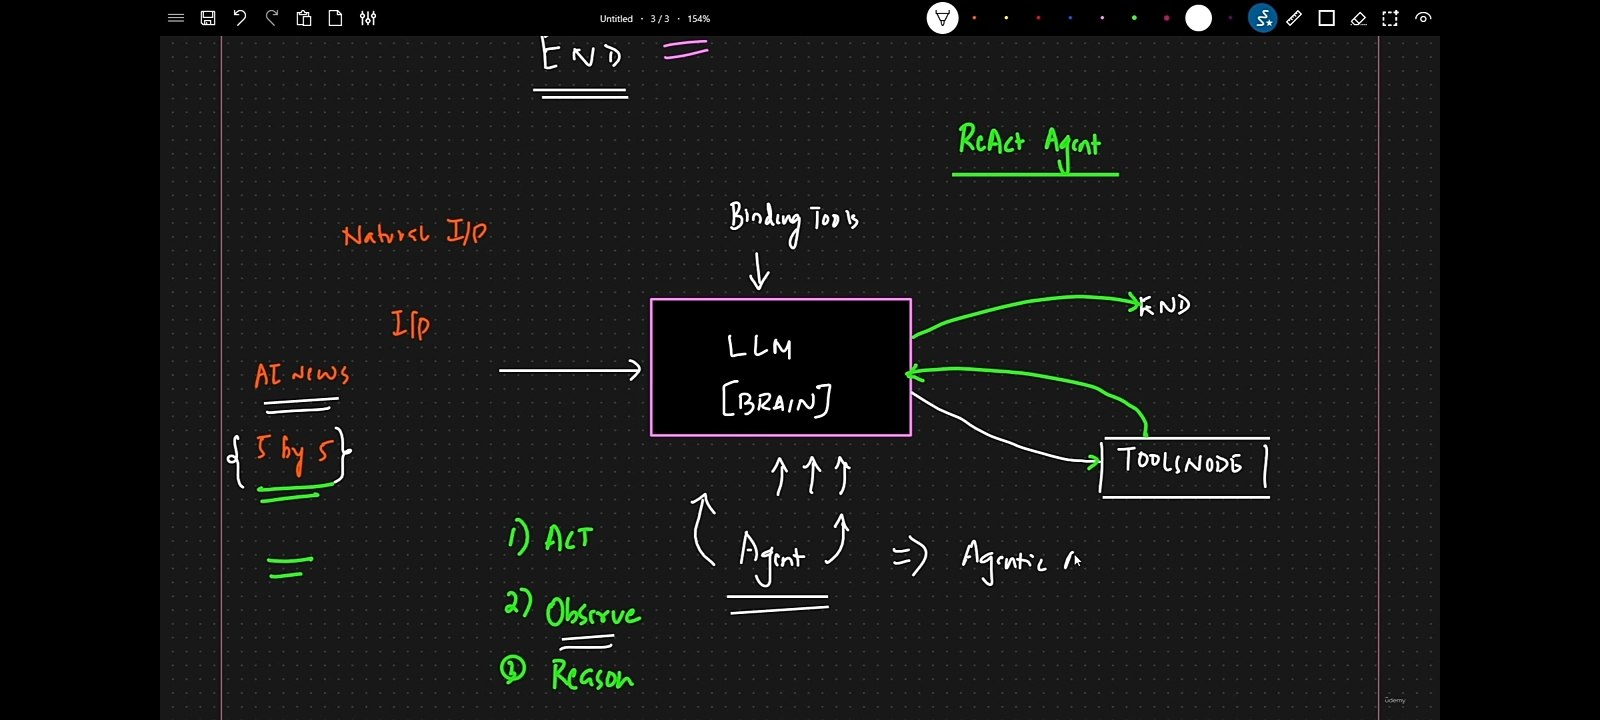

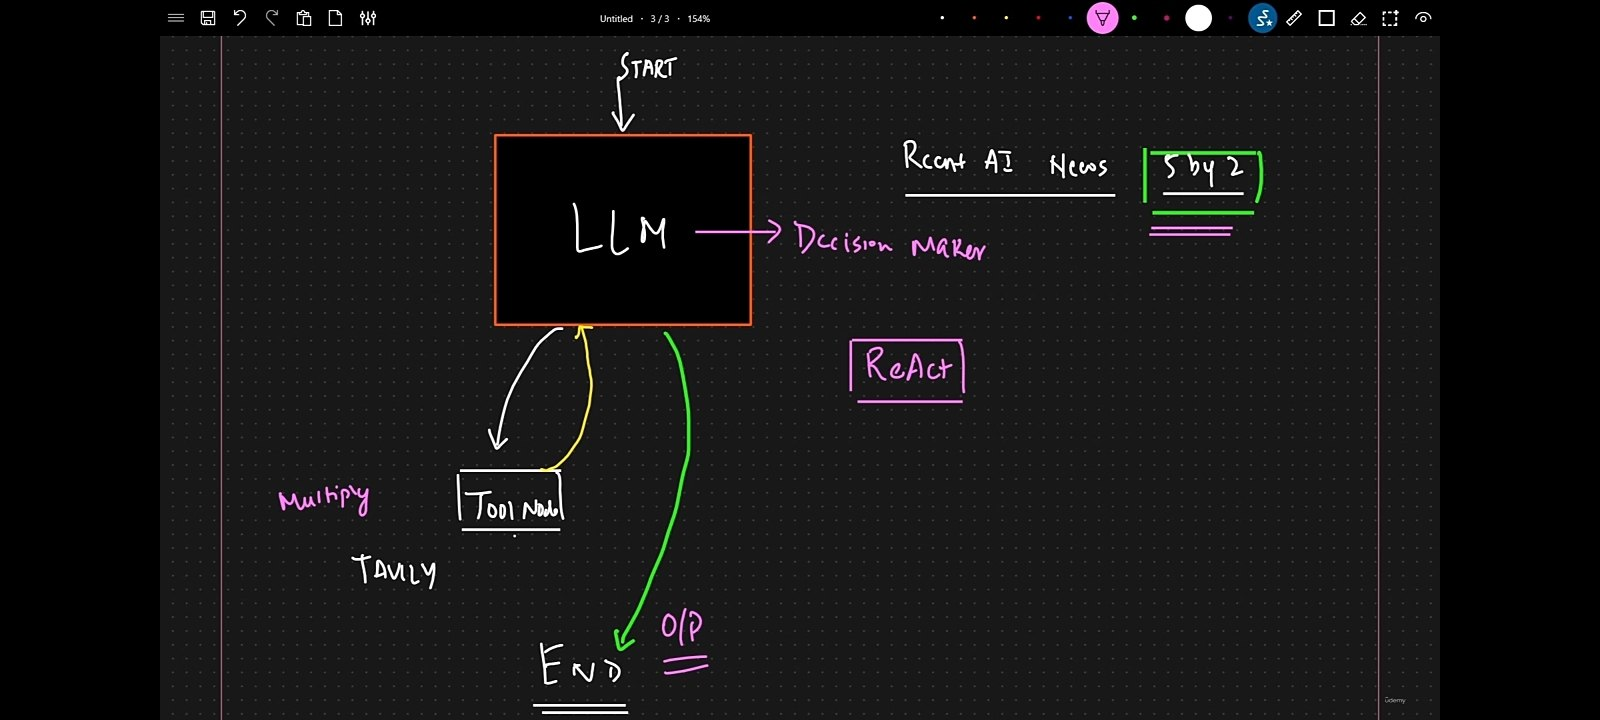

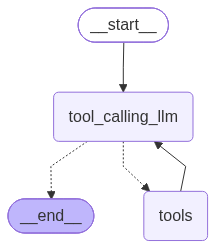

In [32]:
## Stategraph

from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node defination

def tool_calling_llm(state:State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}
   


## Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
    # If the latest message (result) from assitant is a tool call --> tools_condition routes to tools
    # If the latest_message (result) from assitant is a not tool call _> tools_condition routes to end
)

builder.add_edge("tools","tool_calling_llm")


## Compile the graph 
graph=builder.compile()

from IPython.display import Image , display
display(Image(graph.get_graph().draw_mermaid_png()))

In [33]:
response=graph.invoke({"messages":" give me  recent AI News and then what is  2 multiply by 3 and then multiply by 10"})

for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

 give me  recent AI News and then what is  2 multiply by 3 and then multiply by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (chatcmpl-tool-bfa712be57edd735)
 Call ID: chatcmpl-tool-bfa712be57edd735
  Args:
    query: recent AI news
    time_range: week
    search_depth: basic
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.youtube.com/watch?v=Laws8go7v98", "title": "41 Stats About AI Adoption", "content": "# 41 Stats About AI Adoption\n## The AI Daily Brief: Artificial Intelligence News\n584000 subscribers\n119 likes\n\n### Description\n3906 views\nPosted: 11 Aug 2026\nAI is now used by a majority of American workers—but the gap between the frontier and everyone else 

## Adding Memory In Agentic Graph

In [34]:
response=graph.invoke({"messages":"Hello My name is Chinmay"})
for m in response['messages']:
    m.pretty_print()


================================ Human Message =================================

Hello My name is Chinmay
================================== Ai Message ==================================

Hello Chinmay! It's nice to meet you. How can I help you today?


In [35]:
response=graph.invoke({"messages":"What is My name"})
for m in response['messages']:
    m.pretty_print()


================================ Human Message =================================

What is My name
================================== Ai Message ==================================

I don’t have any information about your name. If you’d like to share it, I’ll be happy to use it in our conversation!


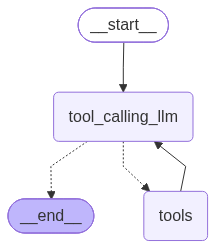

In [38]:
## Stategraph

from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# langraph Memory
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## Node defination

def tool_calling_llm(state:State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}
   


## Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
    # If the latest message (result) from assitant is a tool call --> tools_condition routes to tools
    # If the latest_message (result) from assitant is a not tool call _> tools_condition routes to end
)

builder.add_edge("tools","tool_calling_llm")


## Compile the graph 
graph=builder.compile(checkpointer = memory )

from IPython.display import Image , display
display(Image(graph.get_graph().draw_mermaid_png()))

In [42]:
config={"configurable":{"thread_id":"1"}}

response=graph.invoke({"messages":"hii My name is chinmay"}, config = config)

response

{'messages': [HumanMessage(content='hii My name is chinmay', additional_kwargs={}, response_metadata={}, id='6b11ca37-4f37-4d34-b1ab-1c2475cd0e5f'),
  AIMessage(content="Hi Chinmay! 👋 It's nice to meet you. How can I help you today? Is there something you'd like to know, discuss, or work on together?", additional_kwargs={'reasoning_content': "Hello! I'm happy to meet you, Chinmay. How can I assist you today? Is there something specific you'd like to know or discuss?", '_reasoning_api_fields': ['reasoning_content']}, response_metadata={'content': "Hi Chinmay! 👋 It's nice to meet you. How can I help you today? Is there something you'd like to know, discuss, or work on together?", 'role': 'assistant', 'reasoning_content': "Hello! I'm happy to meet you, Chinmay. How can I assist you today? Is there something specific you'd like to know or discuss?", 'token_usage': {'prompt_tokens': 1974, 'completion_tokens': 71, 'total_tokens': 2045}, 'finish_reason': 'stop', 'model_name': 'nvidia/nemotron

In [44]:
config={"configurable":{"thread_id":"1"}}

response=graph.invoke({"messages":"Do You know what is my name"}, config = config)

response

{'messages': [HumanMessage(content='hii My name is chinmay', additional_kwargs={}, response_metadata={}, id='6b11ca37-4f37-4d34-b1ab-1c2475cd0e5f'),
  AIMessage(content="Hi Chinmay! 👋 It's nice to meet you. How can I help you today? Is there something you'd like to know, discuss, or work on together?", additional_kwargs={'reasoning_content': "Hello! I'm happy to meet you, Chinmay. How can I assist you today? Is there something specific you'd like to know or discuss?", '_reasoning_api_fields': ['reasoning_content']}, response_metadata={'content': "Hi Chinmay! 👋 It's nice to meet you. How can I help you today? Is there something you'd like to know, discuss, or work on together?", 'role': 'assistant', 'reasoning_content': "Hello! I'm happy to meet you, Chinmay. How can I assist you today? Is there something specific you'd like to know or discuss?", 'token_usage': {'prompt_tokens': 1974, 'completion_tokens': 71, 'total_tokens': 2045}, 'finish_reason': 'stop', 'model_name': 'nvidia/nemotron

In [45]:
response=graph.invoke({"messages":"hey what is my name"},config=config)

print(response['messages'][-1].content)



Your name is **chinmay**! 😊 You told me that when we first started chatting. Is there anything else you'd like to talk about?


In [46]:
response=graph.invoke({"messages":"hey do you remember  what is my name"},config=config)

print(response['messages'][-1].content)



Yes! I definitely remember — your name is **chinmay**! 😊 You shared that with me right at the start of our chat, and I’ve kept it in mind throughout our conversation.  

Is there something else you’d like to talk about or ask me now? I’m here to help! 💬


# Streaming 

In [47]:
def superbot(state:State):
    return{"messages":[llm.invoke(state['messages'])]}

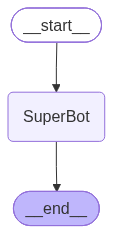

In [52]:

from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

graph = StateGraph(State)

## node 
graph.add_node("SuperBot",superbot)

## Edges
graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)

Graph_builder=graph.compile(checkpointer=memory)

## displya

from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))









In [53]:
## Invocation 

config={"configurable": {"thread_id": "1"}}

response=Graph_builder.invoke({"messages":"hey my name is chinmay Palshetkar i like to play football"},config)

response


{'messages': [HumanMessage(content='hii My name is chinmay', additional_kwargs={}, response_metadata={}, id='6b11ca37-4f37-4d34-b1ab-1c2475cd0e5f'),
  AIMessage(content="Hi Chinmay! 👋 It's nice to meet you. How can I help you today? Is there something you'd like to know, discuss, or work on together?", additional_kwargs={'reasoning_content': "Hello! I'm happy to meet you, Chinmay. How can I assist you today? Is there something specific you'd like to know or discuss?", '_reasoning_api_fields': ['reasoning_content']}, response_metadata={'content': "Hi Chinmay! 👋 It's nice to meet you. How can I help you today? Is there something you'd like to know, discuss, or work on together?", 'role': 'assistant', 'reasoning_content': "Hello! I'm happy to meet you, Chinmay. How can I assist you today? Is there something specific you'd like to know or discuss?", 'token_usage': {'prompt_tokens': 1974, 'completion_tokens': 71, 'total_tokens': 2045}, 'finish_reason': 'stop', 'model_name': 'nvidia/nemotron

In [54]:
### Create a thread


config = {"configurable":{"thread_id": "3"}}

for chunk in Graph_builder.stream({'messages':"hii , My name is Chinmay and i like to play football"},config,stream_mode="updates"):
    print(chunk)



{'SuperBot': {'messages': [AIMessage(content="Hey Chinmay! 👋 Nice to meet you—football is awesome! Whether you're playing for fun, in a team, or just kicking a ball around with friends, that’s the best way to enjoy the game.  \n\nWhat position do you usually play? Or do you have a favorite team/player you love watching? (I’m all ears for football chats! ⚽😄)  \n\nKeep chasing those goals—on and off the pitch! 💪", additional_kwargs={'reasoning_content': 'Okay, the user introduced themselves as Chinmay who likes playing football. They started with a casual "hii" which suggests they\'re relaxed and friendly. \n\nHmm, they didn\'t ask a specific question but shared personal info—probably just wanting to connect or test if I\'ll engage. Since they mentioned football, I should keep the response lively and related to that interest. \n\nNoticing they used lowercase and no punctuation, they might be typing quickly on mobile. I\'ll match that energy with short sentences and emojis to feel approac

In [55]:
for chunk in Graph_builder.stream({'messages':"hii , My name is Chinmay and i like to play football"},config,stream_mode="values"):
    print(chunk)


{'messages': [HumanMessage(content='hii , My name is Chinmay and i like to play football', additional_kwargs={}, response_metadata={}, id='aa81f9f8-7e1c-4f0e-a32c-de028515441a'), AIMessage(content="Hey Chinmay! 👋 Nice to meet you—football is awesome! Whether you're playing for fun, in a team, or just kicking a ball around with friends, that’s the best way to enjoy the game.  \n\nWhat position do you usually play? Or do you have a favorite team/player you love watching? (I’m all ears for football chats! ⚽😄)  \n\nKeep chasing those goals—on and off the pitch! 💪", additional_kwargs={'reasoning_content': 'Okay, the user introduced themselves as Chinmay who likes playing football. They started with a casual "hii" which suggests they\'re relaxed and friendly. \n\nHmm, they didn\'t ask a specific question but shared personal info—probably just wanting to connect or test if I\'ll engage. Since they mentioned football, I should keep the response lively and related to that interest. \n\nNoticing

In [56]:
### Create a thread


config = {"configurable":{"thread_id": "4"}}

for chunk in Graph_builder.stream({'messages':"hii , My name is Chinmay and i like to play football"},config,stream_mode="updates"):
    print(chunk)


{'SuperBot': {'messages': [AIMessage(content="Hey Chinmay! 👋 Nice to meet you — football is awesome! Whether you're playing for fun with friends, on a team, or just love watching matches, it’s such a great sport.  \n\nWhat position do you usually play? Or if you're more into watching — any favorite team or player? (No pressure to answer — just curious! ⚽)  \n\nHope you’re having a great day! 😊", additional_kwargs={'reasoning_content': 'Okay, the user introduced themselves as Chinmay who likes to play football. Simple and friendly greeting. \n\nHmm, they didn\'t ask a specific question but shared a personal detail. Probably wants to start a conversation about football. Since they used "hii" with double i, seems casual and maybe a bit enthusiastic. \n\nI should match their energy - warm and open-ended to encourage more sharing. Football is a great topic! Could ask about position, favorite team, or if they play casually/competitively. \n\nNoticing they didn\'t mention location or age - bu

In [57]:
for chunk in Graph_builder.stream({'messages':"hii , My name is Chinmay and i like to play cricket"},config,stream_mode="values"):
    print(chunk)


{'SuperBot': {'messages': [AIMessage(content="Hey Chinmay! 👋 Thanks for the correction — cricket is an *amazing* sport! 🏏 Whether you're smashing sixes, bowling fiery spells, or fielding with laser focus, it’s such a thrilling game.  \n\nWhat’s your favorite part of playing? Are you more of a batsman, bowler, or all-rounder? (Or maybe you just love the gully cricket vibes with friends? 😄)  \n\nAnd hey — if you’ve got a favorite team or player (Virat? Babar? Rashid Khan?), I’d love to hear! Hope you’re having a great day — keep swinging for the fences! 💥🌟", additional_kwargs={'reasoning_content': 'Okay, the user just corrected their interest from football to cricket after my initial response. Hmm, interesting shift—first they said football, now cricket. Maybe they typed quickly and made a mistake, or perhaps they\'re testing if I notice the change? Either way, I should roll with it gracefully.  \n\nChinmay seems friendly and casual—they used "hii" twice and kept it simple. Since they co

In [58]:
for chunk in Graph_builder.stream({'messages':"hii , My name is Chinmay and i like to play cricket"},config,stream_mode="values"):
    print(chunk)


{'messages': [HumanMessage(content='hii , My name is Chinmay and i like to play football', additional_kwargs={}, response_metadata={}, id='1b77e5c5-70e2-43f9-8e3e-ddcc8b688eb0'), AIMessage(content="Hey Chinmay! 👋 Nice to meet you — football is awesome! Whether you're playing for fun with friends, on a team, or just love watching matches, it’s such a great sport.  \n\nWhat position do you usually play? Or if you're more into watching — any favorite team or player? (No pressure to answer — just curious! ⚽)  \n\nHope you’re having a great day! 😊", additional_kwargs={'reasoning_content': 'Okay, the user introduced themselves as Chinmay who likes to play football. Simple and friendly greeting. \n\nHmm, they didn\'t ask a specific question but shared a personal detail. Probably wants to start a conversation about football. Since they used "hii" with double i, seems casual and maybe a bit enthusiastic. \n\nI should match their energy - warm and open-ended to encourage more sharing. Football i

### Streaming 
Methods: .stream() and astream()

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- **values** : This streams the full state of the graph after each node is called.
- **updates** : This streams updates to the state of the graph after each node is called.